#Travel Tide Projekt Explorative Datenanalyse (EDA)


### 1. CSV-Datei laden & erste Datenüberprüfung
 In diesem Abschnittwird die explorative Nutzertabelle geladen und für die Analyse vorbereitet.

In [ ]:
import pandas as pd

df = pd.read_csv("finale_nutzertabelle_final_user_base_table-2026-04-08_42754.csv")
df.head()

,user_id,total_sessions,total_clicks,avg_clicks_per_session,flights_booked,hotels_booked,cancellations,avg_flight_discount,avg_hotel_discount,avg_discount_total,conversion_rate,cancellation_rate,booking_type,customer_value
0,0,11,145,13.181818,2,2,0,0.013636,0.000000,0.013636,0.363636,0.000000,both,Medium Value
1,1,7,156,22.285714,4,5,1,0.000000,0.075000,0.064286,1.285714,0.142857,both,Medium Value
2,2,8,221,27.625000,4,3,0,0.000000,0.018750,0.018750,0.875000,0.000000,both,High Value
3,3,9,143,15.888889,2,4,0,0.016667,0.022222,0.038889,0.666667,0.000000,both,High Value
4,4,10,125,12.500000,2,2,0,0.000000,0.000000,0.000000,0.400000,0.000000,both,Medium Value


## 2. Überblick über den Datensatz
In diesem Abschnitt werden Struktur, Inhalt, Datentypen, statistische Kennzahlen und fehlende Werte des Datewnsatzes überprüft.

In [ ]:
df = pd.read_csv("/content/finale_nutzertabelle_final_user_base_table-2026-04-08_42754.csv")

In [ ]:
from sklearn.preprocessing import StandardScaler

segmentation_features = [
    'total_sessions',
    'total_clicks',
    'avg_clicks_per_session',
    'flights_booked',
    'hotels_booked',
    'cancellations',
    'avg_discount_total',
    'conversion_rate',
    'cancellation_rate'
]

df_seg = df[segmentation_features].copy()

scaler = StandardScaler()
df_seg_scaled = scaler.fit_transform(df_seg)

print("Scaling done")
print(df_seg.shape)

Scaling done
(50000, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 50000 non-null  int64  
 1   total_sessions          50000 non-null  int64  
 2   total_clicks            50000 non-null  int64  
 3   avg_clicks_per_session  50000 non-null  float64
 4   flights_booked          50000 non-null  int64  
 5   hotels_booked           50000 non-null  int64  
 6   cancellations           50000 non-null  int64  
 7   avg_flight_discount     50000 non-null  float64
 8   avg_hotel_discount      50000 non-null  float64
 9   avg_discount_total      50000 non-null  float64
 10  conversion_rate         50000 non-null  float64
 11  cancellation_rate       50000 non-null  float64
 12  booking_type            50000 non-null  object 
 13  customer_value          50000 non-null  object 
dtypes: float64(6), int64(6), object(2)
mem

In [ ]:
df.describe()

,user_id,total_sessions,total_clicks,avg_clicks_per_session,flights_booked,hotels_booked,cancellations,avg_flight_discount,avg_hotel_discount,avg_discount_total,conversion_rate,cancellation_rate
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,8.97216,173.194960,19.432336,3.332680,3.358120,0.193500,0.023310,0.014421,0.036881,0.748888,0.022803
std,14433.901067,1.83431,82.388604,9.094067,1.878402,1.810794,0.429909,0.021878,0.015258,0.026233,0.369356,0.053763
min,0.000000,1.00000,8.000000,3.875000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12499.750000,8.00000,119.000000,14.000000,2.000000,2.000000,0.000000,0.005556,0.000000,0.016667,0.500000,0.000000
50%,24999.500000,9.00000,155.000000,17.222222,3.000000,3.000000,0.000000,0.018750,0.011111,0.033333,0.750000,0.000000
75%,37499.250000,10.00000,204.000000,21.625000,5.000000,5.000000,0.000000,0.035714,0.022222,0.050000,1.000000,0.000000
max,49999.000000,17.00000,816.000000,132.500000,11.000000,12.000000,3.000000,0.350000,0.275000,0.350000,2.000000,0.500000


In [ ]:
df.isnull().sum()


,0
user_id,0
total_sessions,0
total_clicks,0
avg_clicks_per_session,0
flights_booked,0
hotels_booked,0
cancellations,0
avg_flight_discount,0
avg_hotel_discount,0
avg_discount_total,0


## 3. Variablenstruktur und numerische Merkmale
In diesem Abschnitt werden die verfügbaren Variablenüberprüft und die numerischen Features für die weitere Analyse identifiziert.

In [ ]:
df.columns

Index(['user_id', 'total_sessions', 'total_clicks', 'avg_clicks_per_session',
       'flights_booked', 'hotels_booked', 'cancellations',
       'avg_flight_discount', 'avg_hotel_discount', 'avg_discount_total',
       'conversion_rate', 'cancellation_rate', 'booking_type',
       'customer_value'],
      dtype='object')

In [ ]:
df.shape

(50000, 14)

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('user_id')
numeric_cols

Index(['total_sessions', 'total_clicks', 'avg_clicks_per_session',
       'flights_booked', 'hotels_booked', 'cancellations',
       'avg_flight_discount', 'avg_hotel_discount', 'avg_discount_total',
       'conversion_rate', 'cancellation_rate'],
      dtype='object')

## 4. Verteilungsanalyse numerischer Variablen
In diesem Abschnitt werden die numerischen Variablen visuell untersucht, um Verteilungen, Außreißer, Schiefe und potenzielle Muster für die spätere Segmentierung zu erkennen.

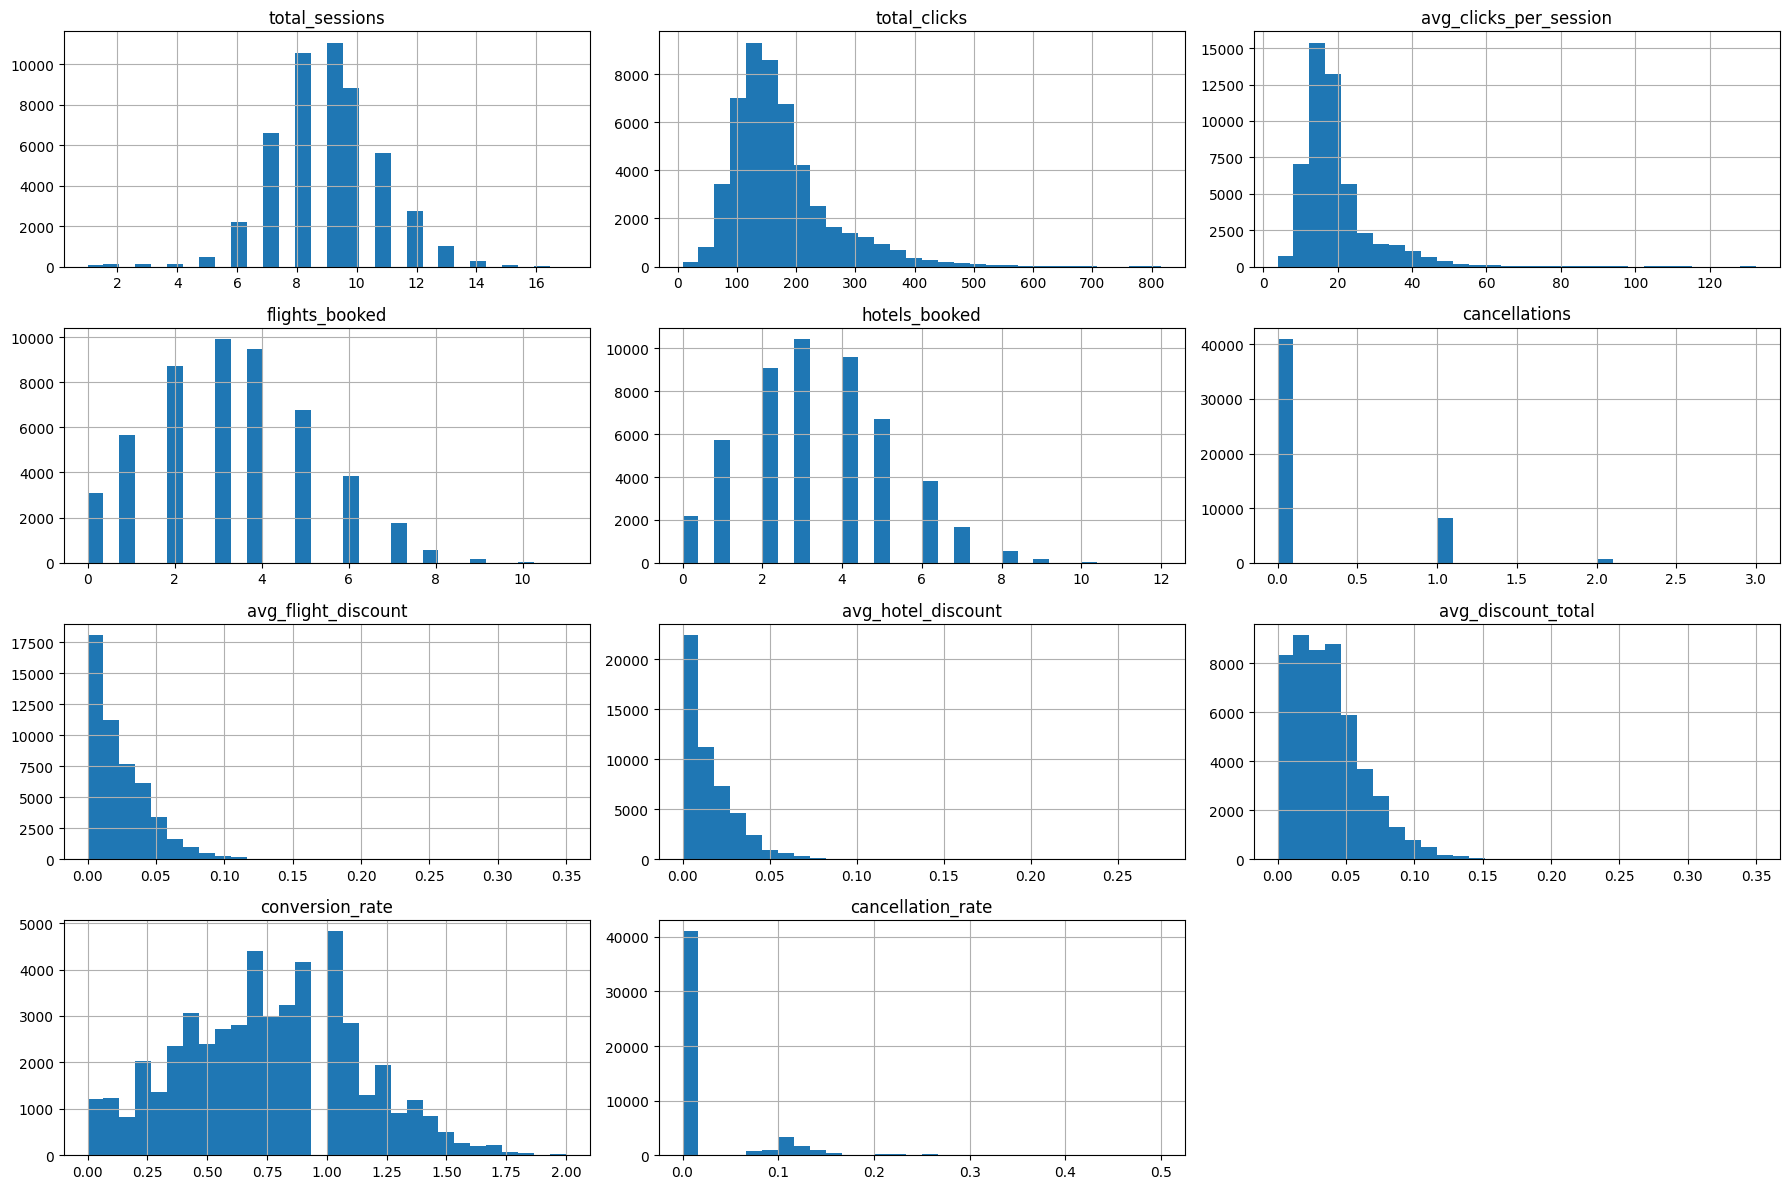

In [ ]:
df[numeric_cols].hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

## 5. Erste Interpretation der Verteilungen

Die Verteilungen der numerischen Variablen zeigen, dass das Nutzerverhalten auf der TravelTide-Plattform nicht gleichmäßig verteilt ist.

Mehrere Variablen – insbesondere ⁠ total_clicks ⁠, ⁠ avg_clicks_per_session ⁠, ⁠ avg_flight_discount ⁠, ⁠ avg_hotel_discount ⁠, ⁠ avg_discount_total ⁠ und ⁠ cancellation_rate ⁠ – weisen eine rechtsschiefe Verteilung auf. Das bedeutet, dass die Mehrheit der Nutzer eher moderate oder niedrige Werte aufweist, während nur ein kleiner Teil der Nutzer besonders aktiv ist, höhere Rabatte erhält oder häufiger storniert.

Demgegenüber zeigen Variablen wie ⁠ total_sessions ⁠, ⁠ flights_booked ⁠ und ⁠ hotels_booked ⁠ eher kompaktere Verteilungen und liefern Hinweise auf typische Nutzungs- und Buchungsmuster.

Besonders relevant für die spätere Kundensegmentierung erscheinen Variablen wie ⁠ total_clicks ⁠, ⁠ avg_clicks_per_session ⁠, ⁠ conversion_rate ⁠, ⁠ avg_discount_total ⁠ und ⁠ cancellation_rate ⁠, da sie Unterschiede im Nutzerverhalten, in der Buchungswahrscheinlichkeit und in der Wertigkeit der Kunden besonders gut abbilden können.

## 6. Auswahl relevanter Features für die Segmentierung

Nicht alle Variablen des Datensatzes sind gleichermaßen für die Kundensegmentierung geeignet. Ziel der Segmentierung ist es, Nutzer anhand ihres Verhaltens, ihrer Aktivität, ihrer Buchungswahrscheinlichkeit und ihres Preis- bzw. Rabattverhaltens sinnvoll zu gruppieren.

Für die weitere Segmentierungsanalyse erscheinen insbesondere folgende Variablen geeignet:

•⁠  ⁠⁠ total_sessions ⁠
•⁠  ⁠⁠ total_clicks ⁠
•⁠  ⁠⁠ avg_clicks_per_session ⁠
•⁠  ⁠⁠ flights_booked ⁠
•⁠  ⁠⁠ hotels_booked ⁠
•⁠  ⁠⁠ cancellations ⁠
•⁠  ⁠⁠ avg_flight_discount ⁠
•⁠  ⁠⁠ avg_hotel_discount ⁠
•⁠  ⁠⁠ avg_discount_total ⁠
•⁠  ⁠⁠ conversion_rate ⁠
•⁠  ⁠⁠ cancellation_rate ⁠

Nicht direkt für die numerische Segmentierung verwendet werden sollten dagegen:

•⁠  ⁠⁠ user_id ⁠ → reine Identifikationsvariable ohne analytischen Mehrwert
•⁠  ⁠⁠ booking_type ⁠ → kategoriale Ziel-/Beschreibungsspalte
•⁠  ⁠⁠ customer_value ⁠ → bereits abgeleitete Business-Klassifikation und eher zur späteren Interpretation als zur eigentlichen Segmentbildung geeignet.

In [ ]:
segmentation_features = [
    'total_sessions',
    'total_clicks',
    'avg_clicks_per_session',
    'flights_booked',
    'hotels_booked',
    'cancellations',
    'avg_flight_discount',
    'avg_hotel_discount',
    'avg_discount_total',
    'conversion_rate',
    'cancellation_rate'
]

df_seg = df[segmentation_features]
df_seg.head()

,total_sessions,total_clicks,avg_clicks_per_session,flights_booked,hotels_booked,cancellations,avg_flight_discount,avg_hotel_discount,avg_discount_total,conversion_rate,cancellation_rate
0,11,145,13.181818,2,2,0,0.013636,0.000000,0.013636,0.363636,0.000000
1,7,156,22.285714,4,5,1,0.000000,0.075000,0.064286,1.285714,0.142857
2,8,221,27.625000,4,3,0,0.000000,0.018750,0.018750,0.875000,0.000000
3,9,143,15.888889,2,4,0,0.016667,0.022222,0.038889,0.666667,0.000000
4,10,125,12.500000,2,2,0,0.000000,0.000000,0.000000,0.400000,0.000000


## 7. Skalierung der Features für die Segmentierung

Da die ausgewählte Variable auf unterschiedliche Skalen vorliegen, werden sie vor der Clusteranalyse standatisiert. Dadurch wird sichergestellt, dass keine einzelnen Variablen aufgrund ihrer Größe eine unverhältmäßig starken Einfluss auf die Segmentierunf ausübt.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Skalierung der Segmentierungsdaten
scaler = StandardScaler()
df_seg_scaled = scaler.fit_transform(df_seg)

# In DataFrame zurückwandeln für bessere Übersicht
df_seg_scaled = pd.DataFrame(df_seg_scaled, columns=segmentation_features)

# Vorschau
df_seg_scaled.head()

,total_sessions,total_clicks,avg_clicks_per_session,flights_booked,hotels_booked,cancellations,avg_flight_discount,avg_hotel_discount,avg_discount_total,conversion_rate,cancellation_rate
0,1.105517,-0.342223,-0.687325,-0.709482,-0.750021,-0.450100,-0.442165,-0.945179,-0.886123,-1.043045,-0.424145
1,-1.075162,-0.208708,0.313766,0.355263,0.906727,1.875999,-1.065463,3.970304,1.044677,1.453425,2.233023
2,-0.529992,0.580244,0.900889,0.355263,-0.197772,-0.450100,-1.065463,0.283692,-0.691187,0.341441,-0.424145
3,0.015178,-0.366498,-0.389648,-0.709482,0.354478,-0.450100,-0.303654,0.511261,0.076527,-0.222609,-0.424145
4,0.560347,-0.584977,-0.762300,-0.709482,-0.750021,-0.450100,-1.065463,-0.945179,-1.405954,-0.944593,-0.424145


## 8. Bestimmung der optimalen Clusteranzahl

Um eine sinnvolle Anzahl von Kundensegmenten zu bestimmen, wird die Elbow-Methode verwendet. Dabei wird untersucht, wie sich die sogenannte Within-Cluster Sum of Squares (WCSS) verändert, wenn die Anzahl der Cluster erhöht wird.

Der Punkt, an dem die Kurve sichtbar abflacht („Elbow“), gilt als geeignete Clusteranzahl für die weitere Segmentierung.

In [ ]:
from sklearn.preprocessing import StandardScaler

segmentation_features = [
    'total_sessions',
    'total_clicks',
    'avg_clicks_per_session',
    'flights_booked',
    'hotels_booked',
    'cancellations',
    'avg_discount_total',
    'conversion_rate',
    'cancellation_rate'
]

df_seg = df[segmentation_features].copy()

scaler = StandardScaler()
df_seg_scaled = scaler.fit_transform(df_seg)

print("Scaling done")

Scaling done


## 8.1 Validierung der Clusteranzahl mit dem Silhouette Score

Zusätzlich zur Elbow Method wurde der Silhouette Score verwendet, um die Qualität der Clustertrennung für unterschiedliche Werte von k zu überprüfen.

In [ ]:
# Features für Clustering auswählen
segmentation_features = [
    "total_sessions",
    "total_clicks",
    "avg_clicks_per_session",
    "flights_booked",
    "hotels_booked",
    "cancellations",
    "avg_discount_total",
    "conversion_rate",
    "cancellation_rate"
]

df_seg = df[segmentation_features].copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_seg_scaled = scaler.fit_transform(df_seg)

print("Scaling done")

Scaling done


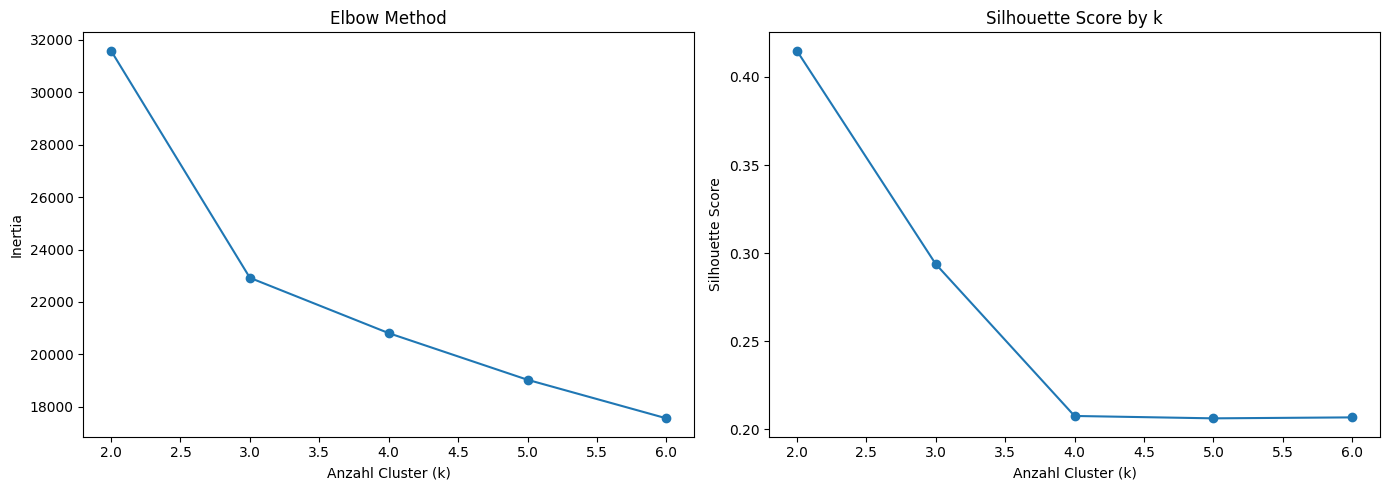

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

# Stichprobe für schnellere Berechnung
df_seg_sample = pd.DataFrame(df_seg_scaled).sample(n=5000, random_state=42)

inertia = []
silhouette_scores = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_seg_sample)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_seg_sample, cluster_labels))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
ax[0].plot(k_values, inertia, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Anzahl Cluster (k)")
ax[0].set_ylabel("Inertia")

# Silhouette Score
ax[1].plot(k_values, silhouette_scores, marker='o')
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("Anzahl Cluster (k)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

## 9. Durchführung der Clusteranalyse

Basierend auf der Elbow-Methode wurde eine Clusteranzahl von vier Segmenten gewählt. Anschließend wurde der K-Means-Algorithmus verwendet, um die Nutzer auf Basis ihres Verhaltens, ihrer Aktivität, ihres Buchungsverhaltens und ihrer Rabattnutzung in homogene Gruppen einzuteilen.

Ziel ist es, Muster innerhalb der Kundendaten sichtbar zu machen und daraus geschäftsrelevante Kundensegmente abzuleiten.

In [ ]:
# KMeans mit 4 Clustern
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Cluster berechnen
df['cluster'] = kmeans.fit_predict(df_seg_scaled)

# Erste Kontrolle
df[['user_id', 'cluster']].head()

,user_id,cluster
0,0,0
1,1,1
2,2,2
3,3,2
4,4,0


## 10. Analyse und Interpretation der Clusterprofile

Nach der Clusterbildung werden die durchschnittlichen Merkmalsausprägungen je Cluster analysiert, um die Unterschiede zwischen den Nutzergruppen besser zu verstehen.

Ziel ist es, aus den technischen Clustern interpretierbare Kundensegmente abzuleiten, die sich hinsichtlich Aktivität, Buchungsverhalten, Rabattnutzung und Stornierungsverhalten unterscheiden.

In [ ]:
# Durchschnittswerte je Cluster berechnen
cluster_profile = df.groupby('cluster')[segmentation_features].mean()

# Ausgabe
cluster_profile

Die Clusterprofile zeigen deutliche Unterschiede zwischen den Nutzergruppen.
Insbesondere variieren die Cluster sichtbar hinsichtlich Aktivität (total_sessions, total_clicks), Buchungsverhalten (flights_booked, hotels_booked), Preisorientierung (avg_discount_total) sowie Konversions- und Stornierungsverhalten (conversion_rate, cancellation_rate).
Diese Unterschiede bestätigen, dass die Cluster nicht zufällig entstanden sind, sondern klar unterscheidbare Verhaltensmuster innerhalb der TravelTide-Nutzerbasis abbilden.

## 11. Benennung und Business-Interpretation der Cluster.        Auf Basis der durchschnittlichen Merkmalsausprägungen lassen sich die vier Cluster in geschäftlich interpretierbare Kundensegmente übersetzen.

### Cluster 0 – Discount-Sensitive Users
Dieses Segment weist eine moderate Aktivität und Buchungswahrscheinlichkeit auf, reagiert jedoch vergleichsweise stärker auf Rabattangebote. Diese Nutzergruppe eignet sich besonders für preisorientierte Promotions und gezielte Angebotskampagnen.

### Cluster 1 – Low Engagement Users
Diese Nutzer zeigen die geringste Aktivität, die niedrigste Buchungsrate und insgesamt das schwächste Engagement. Sie stellen ein Reaktivierungssegment dar, das durch einfache Einstiegsangebote und gezielte Ansprache aktiviert werden könnte.

### Cluster 2 – Highly Active Explorers
Dieses Segment zeigt die höchste Aktivität auf der Plattform, besonders viele Klicks und eine hohe Conversion Rate. Gleichzeitig ist auch das Stornierungsverhalten erhöht, was auf eine stark vergleichs- und explorationsorientierte Nutzergruppe hindeutet.

### Cluster 3 – High Value Bookers
Diese Nutzer weisen die höchste Buchungsintensität und die stärkste Conversion auf. Sie stellen das wertvollste Segment dar und bieten besonderes Potenzial für Kundenbindung, Upselling und personalisierte Premium-Angebote.   

Die Clusterbezeichnungen wurden nicht durch den Algorithmus selbst vergeben, sondern auf Basis der durchschnittlichen Merkmalsausprägungen nachträglich businessseitig interpretiert.
Dadurch werden die analytischen Ergebnisse in geschäftlich verständliche und operativ nutzbare Kundensegmente übersetzt.

## 12. Visualization of Cluster Distribution

Zur besseren Einordnung der Segmentierung wird die Verteilung der Nutzer auf die einzelnen Cluster visualisiert. Dies ermöglicht eine Einschätzung, wie groß die jeweiligen Kundensegmente sind und welche Gruppen den größten Einfluss auf das Gesamtgeschäft haben.

In [ ]:
import matplotlib.pyplot as plt

# Clustergrößen berechnen
cluster_counts = df['cluster'].value_counts().sort_index()

# Business-Namen für die Cluster
cluster_names = {
    0: "Discount-Sensitive Users",
    1: "Low Engagement Users",
    2: "Highly Active Explorers",
    3: "High Value Bookers"
}

# Labels für den Plot
labels = [cluster_names[i] for i in cluster_counts.index]

# Visualisierung
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, cluster_counts.values)

# Titel und Achsen
plt.title("Distribution of Customer Segments", fontsize=14)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)

# X-Achse lesbarer machen
plt.xticks(rotation=20)

# Werte über die Balken schreiben
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Die Visualisierung zeigt die Größenverteilung der identifizierten Kundensegmente innerhalb der TravelTide-Nutzerbasis.

Die Segmentgrößen sind für die geschäftliche Interpretation besonders relevant, da nicht nur das Verhalten eines Segments, sondern auch dessen Anteil an der Gesamtpopulation berücksichtigt werden sollte.

Große Segmente können ein besonders hohes wirtschaftliches Potenzial besitzen, selbst wenn ihre individuelle Conversion oder ihr Kundenwert geringer ist. Gleichzeitig können kleinere, aber hochprofitable Segmente strategisch besonders wertvoll für gezielte Kundenbindungs- und Upselling-Maßnahmen sein.

Die Clusterverteilung liefert damit eine wichtige Grundlage für die Priorisierung zukünftiger Marketing-, Pricing- und Personalisierungsmaßnahmen.

Die Verteilung zeigt, dass sowohl gering engagierte Nutzer als auch wertvolle Vielbucher einen großen Anteil an der Nutzerbasis ausmachen.
Dies ist geschäftlich besonders relevant, da TravelTide damit gleichzeitig ein großes Reaktivierungspotenzial sowie ein starkes Umsatzpotenzial innerhalb bestehender Kundensegmente besitzt.
Kleinere Cluster wie die hochaktiven Entdecker können trotz geringerer Größe strategisch sehr wertvoll sein, da sie gezielt in Richtung stabiler Buchungen entwickelt werden können.

## 13. Business Insights und Handlungsempfehlungen

Die Clusteranalyse zeigt, dass die Nutzerbasis von TravelTide aus klar unterscheidbaren Kundensegmenten besteht, die sich hinsichtlich Aktivität, Buchungsverhalten, Preisorientierung und wirtschaftlichem Potenzial deutlich unterscheiden.

Aus diesen Unterschieden lassen sich konkrete geschäftliche Handlungsempfehlungen ableiten, die eine gezieltere Ansprache und effizientere Ressourcenverteilung ermöglichen.


### Cluster 0 – Preisorientierte Nutzer

Dieses Segment reagiert besonders sensibel auf Rabatte und Promotions. Die Nutzer zeigen grundsätzlich Buchungsinteresse, benötigen jedoch häufig zusätzliche preisliche Anreize, um zur Conversion zu gelangen.

*Empfehlungen:*
•⁠  ⁠gezielte Rabattkampagnen
•⁠  ⁠dynamische Preisgestaltung
•⁠  ⁠personalisierte Angebotskommunikation
•⁠  ⁠limitierte Promotions zur Conversion-Steigerung

*Geschäftlicher Fokus:*  
Preisbasierte Aktivierung und Conversion-Optimierung.




### Cluster 1 – Gering engagierte Nutzer

Diese Nutzer weisen die niedrigste Aktivität und eine geringe Buchungswahrscheinlichkeit auf. Es handelt sich um ein Reaktivierungssegment mit vergleichsweise schwacher Plattformbindung.

Empfehlungen:
•⁠  ⁠Reaktivierungskampagnen per E-Mail oder Push
•⁠  ⁠vereinfachte Nutzerführung
•⁠  ⁠niedrigschwellige Einstiegsangebote
•⁠  ⁠gezielte Reminder- und Trigger-Kommunikation

Geschäftlicher Fokus:  
Reaktivierung und Reduktion von Inaktivität.


### Cluster 2 – Hochaktive Entdecker

Dieses Segment zeigt eine sehr hohe Aktivität auf der Plattform, viele Klicks und intensives Explorationsverhalten. Gleichzeitig ist auch das Stornierungsverhalten erhöht, was auf Unsicherheit oder Vergleichsorientierung im Buchungsprozess hindeutet.

Empfehlungen:
•⁠  ⁠bessere Entscheidungsunterstützung
•⁠  ⁠transparentere Angebotsdarstellung
•⁠  ⁠Conversion-Optimierung im Checkout-Prozess
•⁠  ⁠stärkere Vertrauenssignale (z. B. Bewertungen, Hinweise, Empfehlungen)

Geschäftlicher Fokus:  
Hohe Aktivität in stabile und abgeschlossene Buchungen überführen.


### Cluster 3 - Wertvolle Vielbuchre
Dieses Segment stellt die wirtschaftlich wertvollsten Nutzer dar. Die Kunden zeigen hohe Buchungsintensität, starke Conversion und ein besonders relevantes Umsatzpotenzial.

Empfehlungen:
•⁠  ⁠Loyalty- und Retention-Programme
•⁠  ⁠exklusive Premium-Angebote
•⁠  ⁠Upselling- und Cross-Selling-Maßnahmen
•⁠  ⁠personalisierte Kundenbindung

Geschäftlicher Fokus:
Kundenwert langfristig sichern und weiter ausbauen.


## 14. Strategische Einordnung der Clusteranalyse

Die Clusteranalyse wurde nicht durchgeführt, um rein technische Gruppen zu erzeugen, sondern um geschäftlich relevante Kundensegmente zu identifizieren, die sich hinsichtlich ihres Verhaltens, ihrer Buchungswahrscheinlichkeit, ihrer Preisorientierung und ihres Umsatzpotenzials unterscheiden.

Die Segmentierung basiert auf Variablen, die für das Geschäftsmodell von TravelTide unmittelbar relevant sind. Dazu zählen insbesondere die Aktivität auf der Plattform, das Buchungsverhalten, die Rabattnutzung sowie das Stornierungsverhalten. Diese Merkmale wurden bewusst ausgewählt, da sie in direktem Zusammenhang mit Conversion, Kundenwert und wirtschaftlichem Potenzial stehen.

Die Auswahl von vier Clustern erfolgte auf Grundlage der Elbow-Methode. Diese zeigte, dass bei vier Clustern ein sinnvoller Kompromiss zwischen analytischer Differenzierung und geschäftlicher Umsetzbarkeit erreicht wird. Weniger Cluster hätten relevante Verhaltensunterschiede verdeckt, während mehr Cluster die Interpretierbarkeit und operative Nutzbarkeit unnötig erschwert hätten.

Die Segmentierung ist besonders wertvoll, weil sie TravelTide ermöglicht, Nutzer nicht als homogene Masse zu betrachten, sondern als differenzierte Kundengruppen mit jeweils eigenen Bedürfnissen, Risiken und Umsatzhebeln.

Dadurch können Marketing-, Pricing- und Personalisierungsmaßnahmen deutlich zielgerichteter eingesetzt werden. Preisorientierte Nutzer können beispielsweise durch kontrollierte Rabattstrategien aktiviert, gering engagierte Nutzer durch Reaktivierungsmaßnahmen angesprochen, hochaktive Entdecker durch Conversion-Optimierung besser zum Abschluss geführt und wertvolle Vielbucher langfristig gebunden werden.

Insgesamt bildet die Clusteranalyse somit eine fundierte datengetriebene Grundlage für strategische Geschäftsentscheidungen und liefert einen klaren Mehrwert für die zukünftige Umsatz- und Kundenwertsteigerung von TravelTide.

## 15. Datenschutz und operative Umsetzbarkeit

Die vorliegende Segmentierungsanalyse basiert auf Verhaltens- und Transaktionsdaten wie Sessions, Klicks, Buchungen, Rabattnutzung und Stornierungsverhalten. Diese Merkmale sind analytisch besonders relevant, da sie direkt mit Aktivität, Conversion und wirtschaftlichem Potenzial zusammenhängen.

Für eine reale Umsetzung der Segmentierung ist jedoch sicherzustellen, dass die Nutzung dieser Daten datenschutzrechtlich und organisatorisch zulässig ist. Auch wenn in dieser Analyse keine direkten Identifikationsmerkmale verwendet wurden, bleibt insbesondere die user_id als pseudonymisierte Kennung datenschutzrelevant.

Damit wird deutlich, dass eine professionelle Clusteranalyse nicht nur analytisch sinnvoll, sondern auch verantwortungsvoll und operativ umsetzbar sein muss.

## 16. Fazit

Die durchgeführte Clusteranalyse zeigt, dass sich die Nutzer von TravelTide klar in unterschiedliche Kundensegmente mit eigenen Verhaltensmustern, Buchungswahrscheinlichkeiten und wirtschaftlichen Potenzialen unterteilen lassen.

Durch die datengetriebene Segmentierung können Marketing-, Pricing- und Personalisierungsmaßnahmen gezielter auf die jeweiligen Nutzergruppen abgestimmt werden. Dadurch entsteht eine fundierte Grundlage, um Conversion, Kundenbindung und langfristigen Kundenwert gezielt zu verbessern.

Insgesamt zeigt die Analyse, wie datenbasierte Kundensegmentierung dazu beitragen kann, geschäftliche Entscheidungen strategischer, effizienter und kundenorientierter zu gestalten.
Die Ergebnisse verdeutlichen zudem, dass datenbasierte Segmentierung einen direkten Beitrag zur Umsatzsteigerung, Effizienzverbesserung und gezielten Kundenansprache leisten kann.

## 17. Abschließende strategische Zusammenfassung

Die Kundensegmentierungsanalyse zeigt, dass die Nutzerbasis von TravelTide nicht homogen ist, sondern aus klar unterscheidbaren Kundengruppen mit unterschiedlichen Verhaltensmustern, Buchungstendenzen, Preisempfindlichkeiten und geschäftlichen Werten besteht.

Aus geschäftlicher Sicht schafft die Segmentierung eine fundierte Grundlage für gezielte Maßnahmen:

•⁠  ⁠Preisorientierte Nutzer sollten mit kontrollierten Promotionsstrategien und conversion-orientierten Angeboten angesprochen werden.
•⁠  ⁠Gering engagierte Nutzer stellen ein Reaktivierungspotenzial dar und benötigen vereinfachte Nutzerpfade sowie gezielte Aktivierungskampagnen.
•⁠  ⁠Hochaktive Entdecker zeigen eine starke Plattforminteraktion, benötigen jedoch bessere Entscheidungsunterstützung und Maßnahmen zur Conversion-Optimierung.
•⁠  ⁠Wertvolle Vielbucher sollten gezielt durch Loyalty-Strategien, Upselling und langfristige Bindungsmaßnahmen priorisiert werden.

Insgesamt ermöglicht die Segmentierung TravelTide, sich von einer breiten, undifferenzierten Kundenansprache hin zu einem personalisierteren, effizienteren und strategisch wertvolleren Kundenmanagement zu entwickeln.